In [8]:
%pip install pandas seaborn matplotlib

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
df = pd.read_csv("../data/cleaned/social_media_cleaned.csv")

df.head()


,age,gender,job_type,daily_social_media_time,social_platform_preference,number_of_notifications,work_hours_per_day,perceived_productivity_score,actual_productivity_score,stress_level,sleep_hours,screen_time_before_sleep,breaks_during_work,uses_focus_apps,has_digital_wellbeing_enabled,coffee_consumption_per_day,days_feeling_burnout_per_month,weekly_offline_hours,job_satisfaction_score
0,56,Male,Unemployed,4.180940,Facebook,61,6.753558,8.040464,7.291555,4.0,5.116546,0.419102,8,False,False,4,11,21.927072,6.336688
1,46,Male,Health,3.249603,Twitter,59,9.169296,5.063368,5.165093,7.0,5.103897,0.671519,7,True,True,2,25,0.000000,3.412427
2,32,Male,Finance,NaN,Twitter,57,7.910952,3.861762,3.474053,4.0,8.583222,0.624378,0,True,False,3,17,10.322044,2.474944
3,60,Female,Unemployed,NaN,Facebook,59,6.355027,2.916331,1.774869,6.0,6.052984,1.204540,1,False,False,0,4,23.876616,1.733670
4,38,Male,Finance,1.512568,Twitter,50,6.429312,NaN,4.081026,5.0,5.515251,1.518612,5,False,True,5,2,0.000000,4.568728


In [10]:
df["productivity_score"] = (
    df["work_hours_per_day"] * 0.35 +
    df["sleep_hours"] * 0.25 -
    df["daily_social_media_time"] * 0.25 -
    df["stress_level"] * 0.15
)


In [11]:
df["productivity_score"] = (
    (df["productivity_score"] - df["productivity_score"].min()) /
    (df["productivity_score"].max() - df["productivity_score"].min())
) * 100


In [12]:
df[["productivity_score"]].head()


,productivity_score
0,53.323774
1,60.457574
2,NaN
3,NaN
4,59.066630


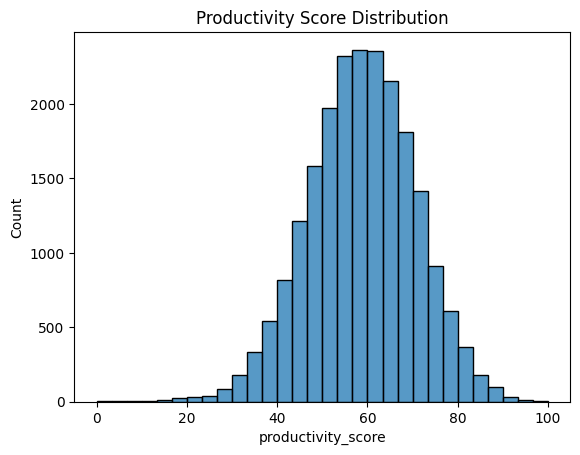

In [13]:
sns.histplot(df["productivity_score"], bins=30)

plt.title("Productivity Score Distribution")

plt.show()


In [14]:
def productivity_level(score):
    
    if score >= 75:
        return "High Productivity"
    
    elif score >= 50:
        return "Moderate Productivity"
    
    else:
        return "Low Productivity"


df["productivity_level"] = df["productivity_score"].apply(productivity_level)

df[["productivity_score","productivity_level"]].head()


,productivity_score,productivity_level
0,53.323774,Moderate Productivity
1,60.457574,Moderate Productivity
2,NaN,Low Productivity
3,NaN,Low Productivity
4,59.066630,Moderate Productivity


In [15]:
df["productivity_level"].value_counts()


productivity_level
Moderate Productivity    14884
Low Productivity         11041
High Productivity         1710
Name: count, dtype: int64

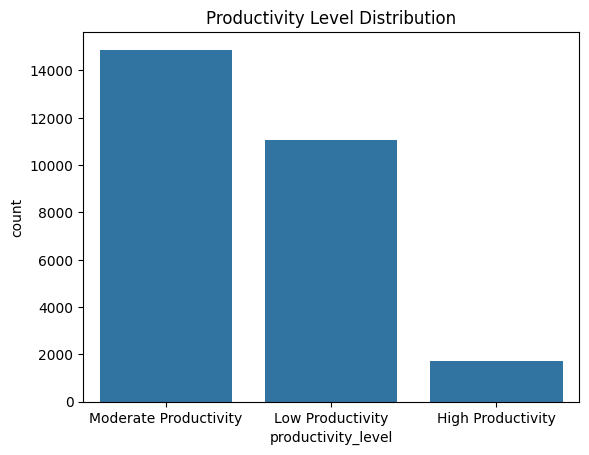

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="productivity_level", data=df)

plt.title("Productivity Level Distribution")
plt.show()


In [17]:
df.to_csv("../data/cleaned/social_media_scored.csv", index=False)


In [1]:
%pip install joblib
%pip install scikit-learn

import joblib
import pandas as pd

# Load model
model = joblib.load("../models/productivity_model.pkl")

# Load column structure
columns = joblib.load("../models/columns.pkl")

print("Model & Columns Loaded")


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached scikit_learn-1.8.0-cp312-cp312-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-win_amd64.whl.metadata (60 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 419.4 kB/s eta 0:00:18
   -- ------------------------------------- 0.5/8.0 MB 419.4 kB/s eta 0:00:18
   --- ------------------------------------ 0.8/8.0 MB 430.4 kB/s eta 0:00:17
   --- ------------------------------------ 0.8/8.0 MB 430.4 kB/s 

c:\Users\Shree\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model & Columns Loaded


c:\Users\Shree\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [2]:
# Create empty input
input_data = pd.DataFrame(columns=columns)

# Add sample values (adjust based on your dataset)
input_data.loc[0] = [
    25,   # age
    1,    # gender (encoded)
    2,    # job_type (encoded)
    3.5,  # daily_social_media_time
    1,    # social_platform_preference
    50,   # number_of_notifications
    8,    # work_hours_per_day
    6,    # stress_level
    7,    # sleep_hours
    2,    # screen_time_before_sleep
    3,    # breaks_during_work
    1,    # uses_focus_apps
    1,    # has_digital_wellbeing_enabled
    2,    # coffee_consumption_per_day
    10,   # days_feeling_burnout_per_month
    20,   # weekly_offline_hours
    7     # job_satisfaction_score
]


ValueError: cannot set a row with mismatched columns

In [3]:
print(columns)


['age', 'daily_social_media_time', 'number_of_notifications', 'work_hours_per_day', 'stress_level', 'sleep_hours', 'screen_time_before_sleep', 'breaks_during_work', 'uses_focus_apps', 'has_digital_wellbeing_enabled', 'coffee_consumption_per_day', 'days_feeling_burnout_per_month', 'weekly_offline_hours', 'job_satisfaction_score', 'gender_Male', 'gender_Other', 'job_type_Finance', 'job_type_Health', 'job_type_IT', 'job_type_Student', 'job_type_Unemployed', 'social_platform_preference_Instagram', 'social_platform_preference_Telegram', 'social_platform_preference_TikTok', 'social_platform_preference_Twitter']


In [4]:
import pandas as pd

# Create empty input
input_data = pd.DataFrame([[0]*len(columns)], columns=columns)


In [ ]:
# Ensure correct dtypes for columns that may contain floats
input_data = input_data.astype({
	'daily_social_media_time': 'float64',
	'work_hours_per_day': 'float64',
	'sleep_hours': 'float64'
})

# Numeric values
input_data.loc[0, "age"] = 25
input_data.loc[0, "daily_social_media_time"] = 3.5
input_data.loc[0, "number_of_notifications"] = 50
input_data.loc[0, "work_hours_per_day"] = 8
input_data.loc[0, "stress_level"] = 6
input_data.loc[0, "sleep_hours"] = 7
input_data.loc[0, "screen_time_before_sleep"] = 2
input_data.loc[0, "breaks_during_work"] = 3
input_data.loc[0, "uses_focus_apps"] = 1
input_data.loc[0, "has_digital_wellbeing_enabled"] = 1
input_data.loc[0, "coffee_consumption_per_day"] = 2
input_data.loc[0, "days_feeling_burnout_per_month"] = 10
input_data.loc[0, "weekly_offline_hours"] = 20
input_data.loc[0, "job_satisfaction_score"] = 7


TypeError: Invalid value '3.5' for dtype 'int64'